# TIME SERIES

Quando temos uma serie temporal, gostaríamos que ela fosse estacionária, com a média não variando (sem tendencia), a variância tambem nao variando e a autocorrelação (independente do tempo) também nao variando, porque assim, simplifica muito minha análise. Existem alguns métodos de transformar uma serie nao estacionaria em estacionaria, veremos a frente, mas antes vamos ver como testar se ela nao é estacionaria.

## Análise gráfica

Podemos ver se uma série é estacionaria pelo gráfico, é uma análise bem grosseira mas da um pontapé inicial

## Teste de Hipótese Augmented Dickey Fuller Test

Aqui a hipótese nula é que a Time Series é não estacionária, então se a estatistica do teste for menor que o valor crítico (dado pelo p valor) nós rejeitamos a hipótese nula e concluímos que a série é estacionária. Este teste é bem mais correto. Para o teste temos que passar o n, numero de lags (defasagens) para o teste. Quando uso maiores n, mais chance de o meu p valor estar coerente.


# Transformar para Estacionário:

## Diferenciação (differencing):

Subtrair valores entre tempos adjacentes da série, desta forma o gráfico irá representar a variação daquilo que estamos medindo. Fica apenas a variaçao no período (incremento) que pode ser estacionário, e caso ainda nao seja, posso fazer diferenciação da diferenciação. Note que essa tecnica é apenas uma tecnica para resolver problema da tendencia, nao da variancia. Fez isso, nao deu, faz de novo e passa ver o incremento de 2 periodos e ai faz de modo recursivo, mas quanto mais voce faz pior, porque voce começa a aproximar demais do valor e overfitar, porque diferenciando muito, no final fica uma reta. (usa maximo de 3)

## Smoothing (Suavização):

Inerente ao dados há alguma variação aleatoria, existem metodos de redução do cancelamento do efeito devido à variação aleatoria, uma tecnica frequente é a suavização. Ela tua pela exponencial, ajuda mais quando quero melhorar a variancia. O alpha modifica bastante a serie.

## Suavização Média Movel

Quanto maior o intervalo de dias selecionados, mais o valor se aproximara da media dos dados como um todo, a media movel é usada para reduzir variabilidade nas tomadas de decisões. Você pode ter efeitos sazonais por exemplo na covid, muito mais casos em alguns dias da semana (por ter mais testes) e ai voce acopla essa sazonalidade na semana e sumariza numa media.
No final de semana muito pouco teste, entao abriríamos tudo se fosse tomar decisão baseado no dia. É importante ter conehcimento do negocio para isso, e em geral quanto mais dias na media movel mais suave a curva porque ela varia menos quando tenho grande variações, porem depende de dados e caracteristicas. A volatilidade da sua media movel faz sentido para a tomada de decisao que voce quer ter? (média movel é a media dos dias anteriores mais o de hoje dividido pelo numero de dias na media movel)  

### Etapas transformação

Realizo transformação e depois avalio serie temporal nesses dados transformados, faço previsao dos dados transformados e volto para os dados reais, pela diferenciação conseguiria apenas colocar as diferenças para os dados que conheço, para a previsao eu nao possuo essa diferença, eu propago o erro de diferenças. Caracterizo meu erro de previsao baseado no meu horizonte, quanto maior o horizonte (tempo a frente) maior meu erro. Incerteza maior em dados muito pra frente. Mas para transformar de volta, voce geralmente nao faz na mao, nos modelos de series tem esse parametro no modelo (note que uma forma seria fazer como faziamos, usa previsao da regressao em conjunto com outros modelos, a regressao deixa estacionario e o outro modelo preve normal) e a saida ja sai corrigida pro real, no caso esses passos eu nao verei, mas faço os passos antes para ver se está bom ou nao, seria o EDA para passar os parâmetros do modelo.



# Identificar modelo usando ACF (autocorrelação) e PACF (autocorrelação parcial -> Parcial autocorrelation function)

É comum iniciarmos fazendo estimativas simples (Naive -Ingenua) para servir de baseline para os demais modelos.

EX:
Repetir o ultimo valor sempre; Utilizar o valor medio; Media rolante; valor medio, etc.

ACF e PACF dao rigor para essas estimativas.

O coeficiente de correlação entre dois valores de uma Time Series é ACF, o ACF de uma serie é dado por:

**ACF = corr(yt, yt-k), em que k é o intervalo de tempo entre os dois valores que queremos medir.**  Como calcular correlação de um vetor com um vetor menor que ele? o yt com o yt-k, entao a gente exclui a mais antiga no yt, mas isso é automatico.

ACF mostra qual a dependencia da variavel com outros valores (anteriores) dela.

**PACF considera os lags parcialmente**  não considera valores intermediarios, ou seja, se quero PACF com um valor é apenas com ele mesmo, ja na ACF considera valores intermediarios, entao ele considera correlação com lag 3 seria com lag3, 2 e 1 construir uma reta e ver quao bem ela esta nos dados. Ja na parcial é apenas o lag 3


# Modelos e Parâmetros


**Modelo AR - Auto Regressive**

A principal ideia de modelos auto regressivos é que o resultado de cada ponto do futuro é função de uma regressão dos valores do passado.

yt = b0 + b1*yt-1 + errot. (AR1 porque so tem um passo para tras) E tem como parâmetro a quantidade de pontos que serão usados na regressão (quantos lags) (AR2 => yt = b0 + b1*yt-1 + b2*yt-2 + errot)

**Modelo MA - Médias Moveis**

Usa apenas a media movel para prever no modelo

**Modelo ARMA (AR + MA)**

Combina os modelos AR e MA e se utiliza dos parâmetros **p** e **q**. O p diz quantos lags para trás irei considerar e o q me diz a dependencia da media movel.

**Modelo ARIMA (AR + Integrated + MA)**

Trata com a diferenciação, tornando series nao estacionarias por estacionarias, surge o parametro **d** de diferenciações (numero de diferenciações).

Ajuda a capturar tendencias tambem

Terminologias do ARIMA que ajudam:

**p** numero de autoregressores, incorpora efeito de valores passados.

**d** Numero de diferenciações que aplicaremos para resolver estacionaridade. Diferenças nao sazonais necessarias para a estacionariedade.

**q** numero de termos da media movel. q é o numero de erros de previsao atrasados na equação da previsao (MA). Isso nos permite definir o  erro do modelo como uma combinação linear dos valores de erro observados em momentos anteriores.

Estes sao os 3 numeros inteiros (p,d,q) para parametrizar o ARIMA, portanto o modelo é chamado **ARIMA(p,d,q)**


**Modelo SARIMA (Seazonal + ARIMA)


Consegue tratar series sazonais e nao estacionarias, possui o parametro **s** que indica em quanto tempo a serie se repete , a sazonalidade se manifesta.

# Métricas de Qualidade

Na prática sao as metricas de regressão.

Lembre-se que horizontes mais próximos você erra menos. Você pode ponderar os erros do MAE por exemplo, que coloca pesos maiores para pontos mais recentes, porque nao posso errar mto perto (WMAE)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
from selenium import webdriver
from time import sleep
from selenium.webdriver.support.ui import Select
import os
import numpy as np
from datetime import datetime
from datetime import timedelta

def remove_unit(x):
    if "%" in x:
        return float(x.split("%")[0])
    else:
        return float(x.split()[0])


def to_time(x):
    return datetime.strptime(x.replace("-","/"), '%Y/%m/%d %H:%M:%S')

def to_inteiro(x):
    return int(x)


def to_month(x):
    return x.month
def to_day(x):
    return x.day
def to_day_(x):
    hour = x.hour
    minutes = x.minute
    seconds = x.second
    return x - timedelta(hours=hour, minutes = minutes, seconds = seconds)
def to_week(x):
    menor = dados["date_order"].min()
    menor = menor - timedelta(hours = 8, minutes=28, seconds = 26 )
    if (menor<=x)&(x<menor + timedelta(7)):
        return menor
    elif(menor+timedelta(7)<=x)&(x<menor+timedelta(14)):
        return menor+timedelta(7)
    elif(menor+timedelta(14)<=x)&(x<menor+timedelta(21)):
        return menor+timedelta(14)
    elif(menor+timedelta(21)<=x)&(x<menor+timedelta(28)):
        return menor+timedelta(21)
    elif(menor+timedelta(28)<=x)&(x<menor+timedelta(35)):
        return menor+timedelta(28)
    elif(menor+timedelta(35)<=x)&(x<menor+timedelta(42)):
        return menor+timedelta(35)
    elif(menor+timedelta(42)<=x)&(x<menor+timedelta(49)):
        return menor+timedelta(42)
    elif(menor+timedelta(49)<=x)&(x<menor+timedelta(56)):
        return menor+timedelta(49)
    elif(menor+timedelta(56)<=x)&(x<menor+timedelta(63)):
        return menor+timedelta(56)
    elif(menor+timedelta(63)<=x)&(x<menor+timedelta(70)):
        return menor+timedelta(63)
    elif(menor+timedelta(70)<=x)&(x<menor+timedelta(77)):
        return menor+timedelta(70)
    elif(menor+timedelta(77)<=x)&(x<menor+timedelta(84)):
        return menor+timedelta(77)
    elif(menor+timedelta(84)<=x)&(x<menor+timedelta(91)):
        return menor+timedelta(84)
    elif(menor+timedelta(91)<=x)&(x<menor+timedelta(98)):
        return menor+timedelta(91)
    elif(menor+timedelta(98)<=x)&(x<menor+timedelta(105)):
        return menor+timedelta(98)
    elif(menor+timedelta(105)<=x)&(x<menor+timedelta(112)):
        return menor+timedelta(105)
    elif(menor+timedelta(112)<=x)&(x<menor+timedelta(119)):
        return menor+timedelta(112)
    elif(menor+timedelta(119)<=x)&(x<menor+timedelta(126)):
        return menor+timedelta(119)
    elif(menor+timedelta(126)<=x)&(x<menor+timedelta(133)):
        return menor+timedelta(126)
    elif(menor+timedelta(133)<=x)&(x<menor+timedelta(140)):
        return menor+timedelta(133)
    elif(menor+timedelta(140)<=x)&(x<menor+timedelta(147)):
        return menor+timedelta(140)
    elif(menor+timedelta(147)<=x)&(x<menor+timedelta(154)):
        return menor+timedelta(147)
    elif(menor+timedelta(154)<=x)&(x<menor+timedelta(161)):
        return menor+timedelta(154)
    elif(menor+timedelta(161)<=x)&(x<menor+timedelta(168)):
        return menor+timedelta(161)
    elif(menor+timedelta(168)<=x)&(x<menor+timedelta(175)):
        return menor+timedelta(168)
    elif(menor+timedelta(175)<=x)&(x<menor+timedelta(182)):
        return menor+timedelta(175)

dados = pd.read_csv("ala.csv")

#pd.set_option('display.max_columns', None)
dados = dados.drop(["Pressão","Visibilidade","Nuvens","Rajada de Vento",
            "Veloc Vento", "Hora", "Dia", "Dia_Hora", "id",
           "ticket_nr", "invoice_eletronic_ids/codigo_retorno",
           "invoice_eletronic_ids/numero", "invoice_eletronic_ids/payment_ids/valor",
           "lines/id", "lines/fiscal_classification_id/code","lines/product_id/id",
           "lines/order_id/id"], axis = 1)


dados["date_order"] = dados["date_order"].apply(to_time)

dados["Chuva"] = dados["Chuva"].apply(remove_unit)
dados["humidade"] = dados["humidade"].apply(remove_unit)
dados["Temperatura"] = dados["Temperatura"].apply(remove_unit)


dados = dados.drop("Sensação", axis = 1)



dados["Temperatura"] = dados["Temperatura"].apply(to_inteiro)


num_prod_temp = dados.pivot_table(index="lines/product_id/name", columns="Temperatura",
                          aggfunc="count", values="lines/product_id/product_variant_ids")



dados["month"] = dados["date_order"].apply(to_month)
dados["day"] = dados["date_order"].apply(to_day)
dados["week"] = dados["date_order"].apply(to_week)
dados["days"] = dados["date_order"].apply(to_day_)



def isNaN(string):
    return string != string
def isnotNaN(string):
    return string == string

sum_unit = []
sum_tot = []
sum_u = 0
sum_t = 0
for pos, i in enumerate(dados["lines/price_unit"]):
    if isNaN(i):
        sum_u = sum_u + 0
        sum_unit.append(sum_u)
    else:
        sum_u = sum_u + i
        sum_unit.append(sum_u)
for pos, i in enumerate(dados["invoice_eletronic_ids/valor_final"]):
    if isNaN(i):
        sum_t = sum_t + 0
        sum_tot.append(sum_t)
    else:
        sum_t = sum_t + i
        sum_tot.append(sum_t)

sum_unit = pd.Series(sum_unit, name = "sum_unit")
sum_tot = pd.Series(sum_tot, name = "sum_tot")

dados = pd.concat([dados,sum_unit,sum_tot], axis = 1)


pd.set_option('display.max_rows', None)
dados[["invoice_eletronic_ids/valor_final","lines/price_unit", "sum_unit", "sum_tot","lines/product_id/name"]]
# MAIS PURE BLACK E LEITE VEGETAL NAO CONTADOS, WTF até 391 -> eram mudanças nos pedidos

pd.set_option('display.max_rows', 5)

dados

,cnpj_cpf,partner_id/display_name,date_order,invoice_eletronic_ids/payment_ids/card_admin,invoice_eletronic_ids/email,invoice_eletronic_ids/valor_final,invoice_eletronic_ids/pos_order_id/name_partner,lines/fiscal_classification_id/category,lines/fiscal_classification_id/descricao_unidade,lines/fiscal_classification_id/name,...,lines/product_id/product_variant_ids,Temperatura,Chuva,humidade,month,day,week,days,sum_unit,sum_tot
0,NaN,Tablet,2021-11-10 19:52:14,Visa,NaN,51.1,MARY,PREPARAÇÕES à,Quilograma,19011010 - LEITE MODIF.P/ALIM D/CRIANÇA P/VEND...,...,[LVG] Leite Vegetal,20,3.4,93.0,11,10,2021-11-08,2021-11-10,5.5,51.1
1,NaN,NaN,2021-11-10 19:52:14,NaN,NaN,NaN,NaN,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",...,[2SC] Salted Caramel,20,3.4,93.0,11,10,2021-11-08,2021-11-10,19.6,51.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24807,NaN,NaN,2021-06-14 08:50:00,NaN,NaN,NaN,NaN,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",...,[1FC] Flat Caramel,20,0.0,69.0,6,14,2021-06-14,2021-06-14,186805.7,186716.2
24808,6.920038e+09,Tablet,2021-06-14 08:28:26,Visa,andremodenesisouza@gmail.com,5.5,Andre,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",...,[2AM] Americano,20,0.0,69.0,6,14,2021-06-14,2021-06-14,186811.2,186721.7


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from pandas.tseries.offsets import DateOffset

In [ ]:
dados = pd.DataFrame(dados.groupby("days")["lines/price_unit"].count())

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 150 entries, 2021-06-14 to 2021-11-10
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   lines/price_unit  150 non-null    int64
dtypes: int64(1)
memory usage: 2.3 KB


In [ ]:
dados = dados.rename(columns = {"lines/price_unit":"Vendas"})

In [ ]:
dados.describe()

,Vendas
count,150.000000
mean,164.546667
...,...
75%,197.500000
max,276.000000


<AxesSubplot:xlabel='days'>

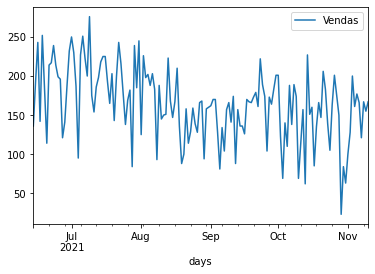

In [ ]:
dados.plot()

## Verificando Estacionariedade

In [ ]:
#Ho: Não é estacionário
#H1: É estacionário

def adfuller_test(Vendas):
    result=adfuller(Vendas)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [ ]:
adfuller_test(dados["Vendas"])

ADF Test Statistic : -2.008940662785597
p-value : 0.282666741879261
#Lags Used : 6
Number of Observations Used : 143
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


# Diferenciação para tornar estacionário

In [ ]:
dados["dif_vendas"] = dados["Vendas"] - dados["Vendas"].shift(1)

In [ ]:
adfuller_test(dados["dif_vendas"].dropna())

ADF Test Statistic : -11.698001948892998
p-value : 1.59354621502015e-21
#Lags Used : 5
Number of Observations Used : 143
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<AxesSubplot:xlabel='days'>

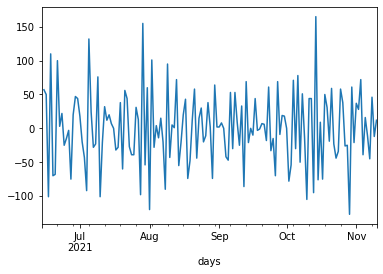

In [ ]:
dados["dif_vendas"].plot()

# Diferenciação Sazonal (Week)

In [ ]:
dados["Seasonal_dif"] = dados["Vendas"] - dados["Vendas"].shift(7)

In [ ]:
dados

,Vendas,dif_vendas,Seasonal_dif
days,,,
2021-06-14,136,NaN,NaN
2021-06-15,193,57.0,NaN
...,...,...,...
2021-11-09,155,-12.0,27.0
2021-11-10,167,12.0,-33.0


In [ ]:
adfuller_test(dados["Seasonal_dif"].dropna())

ADF Test Statistic : -4.402496771891443
p-value : 0.0002938270737031384
#Lags Used : 13
Number of Observations Used : 129
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<AxesSubplot:xlabel='days'>

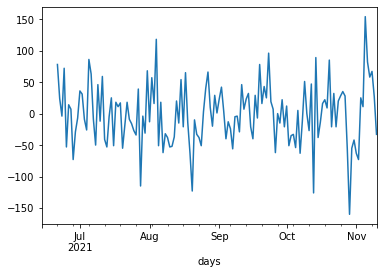

In [ ]:
dados["Seasonal_dif"].plot()

# Modelo Auto Regressivo

yt = b0 + b1*yt-1 + b2*yt-2 +...+bp*yt-p + erro

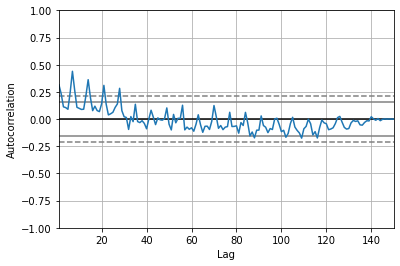

In [ ]:
autocorrelation_plot(dados["Vendas"])
plt.show()

### Sugestões em relação a ACF e PACF

* Identificação do valor de AR é normalmente feito pelo PACF.
    * Num modelo regressivo o PACF "desliga" após a janela decidida.
    
    
* Identificação do valor de MA é normalmente feito pelo ACF.
    * Num modelo de média móvel o valor de PACF não "some", mas vai diminuindo e normalmente chega a zero. Os valores não nulos implicam em todos os intervalos que interagem com a média móvel.
    
    p,d,q
    p AR model lags
    d differencing
    q MA lags

C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


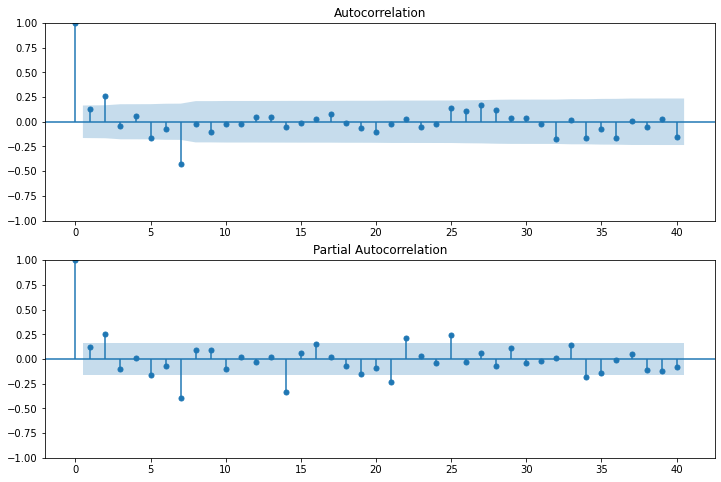

In [ ]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(dados['Seasonal_dif'].iloc[8:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(dados['Seasonal_dif'].iloc[8:],lags=40,ax=ax2)

C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


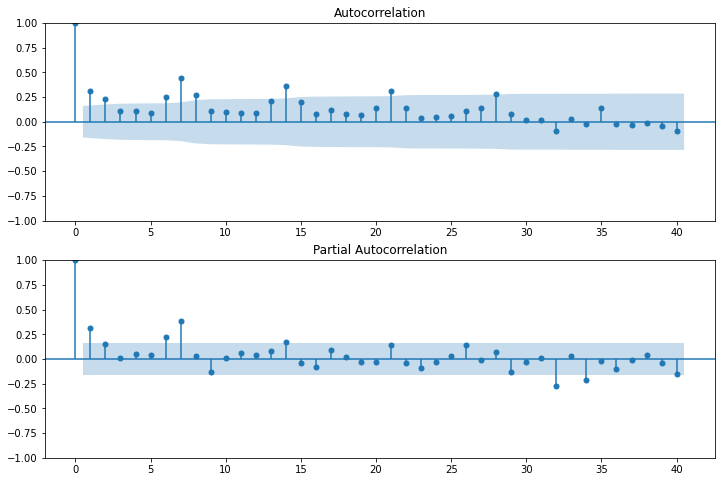

In [ ]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(dados['Vendas'],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(dados['Vendas'],lags=40,ax=ax2)

In [ ]:
model = ARIMA(dados["Vendas"], order = (1,1,1))
model_fit = model.fit()

C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\tsa\base\tsa_model.py:536: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\tsa\base\tsa_model.py:536: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\tsa\base\tsa_model.py:536: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'


In [ ]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Vendas   No. Observations:                  150
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -768.936
Date:                Fri, 19 Nov 2021   AIC                           1543.872
Time:                        15:19:35   BIC                           1552.884
Sample:                    06-14-2021   HQIC                          1547.533
                         - 11-10-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1354      0.097      1.403      0.161      -0.054       0.325
ma.L1         -0.9283      0.043    -21.809      0.000      -1.012      -0.845
sigma2      1757.6039    195.182      9.005      0.000    1375.054    2140.154
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.54
Prob(Q):                              0.97   Prob(JB):                         0.06
Heteroskedasticity (H):               0.98   Skew:                            -0.47
Prob(H) (two-sided):                  0.95   Kurtosis:                         3.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
len(dados)

150

<AxesSubplot:xlabel='days'>

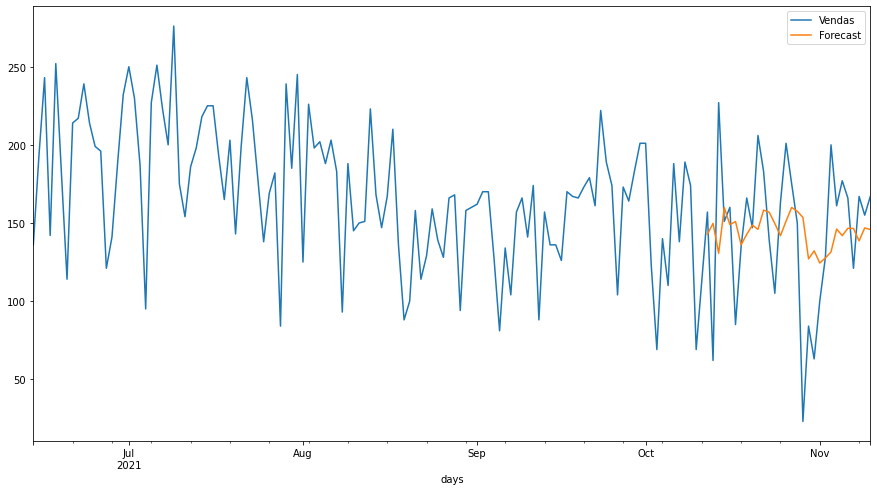

In [ ]:
dados["Forecast"] = model_fit.predict(start = 120, end = 150, dynamic = False)
dados[["Vendas", "Forecast"]].plot(figsize = (15,8))

In [ ]:
model = sm.tsa.statespace.SARIMAX(dados["Vendas"], order = (1,1,1), seasonal_order=(1,1,1,7))
results = model.fit()

C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\tsa\base\tsa_model.py:536: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'
C:\Users\Vaio\anaconda3\envs\dh_pi\lib\site-packages\statsmodels\tsa\base\tsa_model.py:536: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  warnings.warn('No frequency information was'


<AxesSubplot:xlabel='days'>

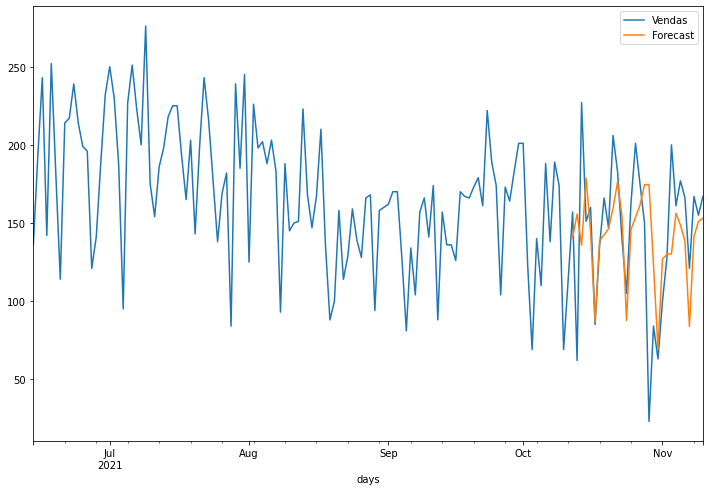

In [ ]:
dados["Forecast"] = results.predict(start = 120, end = 150, dynamic = False)
dados[["Vendas", "Forecast"]].plot(figsize = (12,8))

In [ ]:
future_dates=[dados.index[-1]+ DateOffset(days=x)for x in range(0,24)]

In [ ]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=dados.columns)

In [ ]:
future_datest_df.tail()

,Vendas,dif_vendas,Seasonal_dif,Forecast
2021-11-29,NaN,NaN,NaN,NaN
2021-11-30,NaN,NaN,NaN,NaN
2021-12-01,NaN,NaN,NaN,NaN
2021-12-02,NaN,NaN,NaN,NaN
2021-12-03,NaN,NaN,NaN,NaN


In [ ]:
future_df=pd.concat([dados,future_datest_df])

<AxesSubplot:>

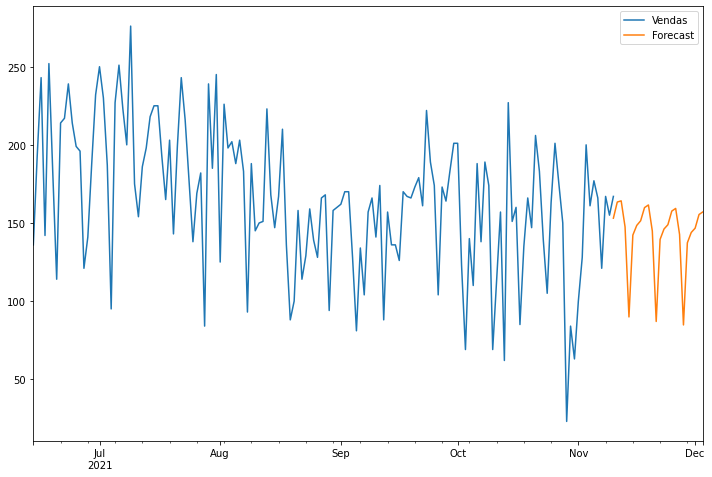

In [ ]:
future_df['Forecast'] = results.predict(start = 149, end = 172, dynamic= False)
future_df[['Vendas', 'Forecast']].plot(figsize=(12, 8))

In [ ]:
import pandas as pd
dados = pd.read_csv("ala.csv")
dados["partner_id/display_name"] = dados["partner_id/display_name"].fillna(method = "ffill")
dados[dados["partner_id/display_name"]=="Smartphone"]["invoice_eletronic_ids/email"].value_counts()

deciobn@gmail.com               78
ana.lucia.gondim@gmail.com      77
laura.dmmd.f@gmail.com          39
peregrin.c@gmail.com            32
dguiarj@gmail.com               32
                                ..
clahiz@msn.com                   1
lpcavalcanti@yahoo.com.br        1
christianvhhtelles@gmail.com     1
joaofdrebelo@gmail.com           1
jalopes@gmail.com                1
Name: invoice_eletronic_ids/email, Length: 539, dtype: int64

In [ ]:
pd.set_option('display.max_columns', None)
dados
#invoice_eletronic_ids/payment_ids/card_admin
#invoice_eletronic_ids/payment_ids/valor
dados["invoice_eletronic_ids/payment_ids/card_admin"] = dados["invoice_eletronic_ids/payment_ids/card_admin"].fillna(method = "ffill")

In [ ]:
# Descrever bebida
dados

,id,cnpj_cpf,partner_id/display_name,ticket_nr,date_order,invoice_eletronic_ids/codigo_retorno,invoice_eletronic_ids/payment_ids/card_admin,invoice_eletronic_ids/payment_ids/valor,invoice_eletronic_ids/email,invoice_eletronic_ids/numero,invoice_eletronic_ids/valor_final,invoice_eletronic_ids/pos_order_id/name_partner,lines/id,lines/fiscal_classification_id/category,lines/fiscal_classification_id/descricao_unidade,lines/fiscal_classification_id/name,lines/fiscal_classification_id/code,lines/price_unit,lines/product_id/id,lines/product_id/name,lines/product_id/product_variant_ids,lines/order_id/id,Dia_Hora,Dia,Hora,Temperatura,Sensação,Veloc Vento,Rajada de Vento,Chuva,humidade,Nuvens,Pressão,Visibilidade
0,__export__.pos_order_2671278_75e501ee,NaN,Tablet,#2671277,2021-11-21 17:56:49,100.0,Mastercard,26.5,NaN,15900.0,26.5,Chico,4585943.0,PREPARAÇÕES à,Quilograma,19011010 - LEITE MODIF.P/ALIM D/CRIANÇA P/VEND...,19011010.0,5.5,310.0,Leite Vegetal,[LVG] Leite Vegetal,__export__.pos_order_2671278_75e501ee,2021-11-21 18:00:00,11/21/2021,18:00,22 °c,22 °c,10 km/h from SE,13 km/h,0.0 mm,73%,97%,1015 mb,Excellent
1,NaN,NaN,Tablet,NaN,2021-11-21 17:56:49,NaN,Mastercard,NaN,NaN,NaN,NaN,NaN,4585944.0,PREPARAÇÕES AL,Quilograma,"21012010 - EXTRATOS, ESSÊNCIAS E CONCENTRADOS ...",21012010.0,12.3,346.0,Matcha Iced Latte,[4MIL] Matcha Iced Latte,__export__.pos_order_2671278_75e501ee,2021-11-21 18:00:00,11/21/2021,18:00,22 °c,22 °c,10 km/h from SE,13 km/h,0.0 mm,73%,97%,1015 mb,Excellent
2,NaN,NaN,Tablet,NaN,2021-11-21 17:56:49,NaN,Mastercard,NaN,NaN,NaN,NaN,NaN,4585945.0,CACAU E SUAS P,Quilograma,18069000 - OUTRAS PREPS.C/CACAU Ñ CIT.ANTERIOR...,18069000.0,8.7,23.0,Urban Chocolat,[4UC] Urban Chocolat,__export__.pos_order_2671278_75e501ee,2021-11-21 18:00:00,11/21/2021,18:00,22 °c,22 °c,10 km/h from SE,13 km/h,0.0 mm,73%,97%,1015 mb,Excellent
3,__export__.pos_order_2671158_c440754f,NaN,Tablet,#2671157,2021-11-21 17:43:12,100.0,Visa,12.4,NaN,15899.0,12.4,Vi,4585718.0,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",21011200.0,12.4,132.0,Iced Vanilla,[1IC] Iced Vanilla,__export__.pos_order_2671158_c440754f,2021-11-21 18:00:00,11/21/2021,18:00,22 °c,22 °c,10 km/h from SE,13 km/h,0.0 mm,73%,97%,1015 mb,Excellent
4,__export__.pos_order_2671016_77d16e35,NaN,Tablet,#2671015,2021-11-21 17:38:33,100.0,Outros,5.2,NaN,15898.0,5.2,T,4585467.0,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",21011200.0,5.2,36.0,Pure Black,[1PB] Pure Black,__export__.pos_order_2671016_77d16e35,2021-11-21 18:00:00,11/21/2021,18:00,22 °c,22 °c,10 km/h from SE,13 km/h,0.0 mm,73%,97%,1015 mb,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26249,NaN,NaN,Smartphone,NaN,2021-06-14 09:12:49,NaN,Visa,NaN,NaN,NaN,NaN,NaN,__export__.pos_order_line_2701466_9152740a,PREPARAÇÕES à,Quilograma,19011010 - LEITE MODIF.P/ALIM D/CRIANÇA P/VEND...,19011010.0,4.5,__export__.product_product_310_1b8c6d37,Leite Vegetal,[LVG] Leite Vegetal,__export__.pos_order_1620556_a82cdcbc,2021-06-14 09:00:00,14/06/2021,09:00,20 °c,20 °c,6 km/h from NNE,8 km/h,0.0 mm,69%,11%,1024 mb,Excellent
26250,NaN,NaN,Smartphone,NaN,2021-06-14 09:12:49,NaN,Visa,NaN,NaN,NaN,NaN,NaN,__export__.pos_order_line_2701467_07b5c546,PREPARAÇÕES à,Quilograma,"19059090 - OUTS.PRODS./PADARIA,PASTELAR.D/INDS...",19059090.0,4.7,__export__.product_product_651_9202fc82,Cookies,[9COOK9] Cookies,__export__.pos_order_1620556_a82cdcbc,2021-06-14 09:00:00,14/06/2021,09:00,20 °c,20 °c,6 km/h from NNE,8 km/h,0.0 mm,69%,11%,1024 mb,Excellent
26251,__export__.pos_order_1620430_f45bbe1e,NaN,Tablet,#1620429,2021-06-14 08:50:00,391.0,Visa,16.3,NaN,2.0,16.3,Marcia,__export__.pos_order_line_2701249_df77fdd1,PREPARAÇÕES AL,Tonel Metr Liquida,"21011200 - PREP.BASE EXTRS.,ESSÊNCIAS/CONCENTR...",21011200.0,8.4,__export__.product_product_369_6369c39d,Mad Mocha,[3MC] Mad Mocha,__export__.